***Import and load structure***

In [1]:
from Bio.PDB import PDBParser
from pathlib import Path

pdb_path = Path("../data/raw/1LYZ.pdb")

parser = PDBParser(QUIET=True)
structure = parser.get_structure("1LYZ", pdb_path)

print("Structure loaded:", structure)

Structure loaded: <Structure id=1LYZ>


***count models***

In [2]:
models = list(structure.get_models())
print("Number of models:", len(models))

Number of models: 1


***count chains***

In [3]:
model = models[0]
chains = list(model.get_chains())

print("Chains:")
for chain in chains:
    print(chain.id)

Chains:
A


***count residues***

In [4]:
from Bio.PDB.Polypeptide import is_aa

residue_count = 0

for residue in model.get_residues():
    if is_aa(residue, standard=True):
        residue_count += 1

print("Number of amino acid residues:", residue_count)

Number of amino acid residues: 129


***count atoms***

In [5]:
atom_count = sum(1 for _ in model.get_atoms())
print("Number of atoms:", atom_count)

Number of atoms: 1102


## Structure Summary (1LYZ)

- Models: 1
- Chains: 1 (Chain A)
- Residues: 129 amino acids
- Atoms: 1102

### Interpretation
This confirms that lysozyme is a small, single-chain protein, making it suitable for structure-based protein engineering and computational design workflows.

***Extract sequence***

In [6]:
from Bio.PDB.Polypeptide import is_aa
from Bio.Data.IUPACData import protein_letters_3to1

model = structure[0]

sequence = []

for residue in model.get_residues():
    if is_aa(residue, standard=True):
        resname = residue.get_resname().capitalize()

        try:
            sequence.append(protein_letters_3to1[resname])
        except KeyError:
            sequence.append("X")  # unknown residue

sequence_str = "".join(sequence)

print("Sequence length:", len(sequence_str))
print("Sequence (first 50 aa):", sequence_str[:50])

Sequence length: 129
Sequence (first 50 aa): KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGS


***Add full sequence print- for visualization***

In [7]:
print(sequence_str)

KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL


***save sequence to file***

In [8]:
from pathlib import Path

output_path = Path("../data/processed/1LYZ_chain_A_sequence.txt")

with open(output_path, "w") as f:
    f.write(sequence_str)

print("Saved sequence to:", output_path)

Saved sequence to: ../data/processed/1LYZ_chain_A_sequence.txt


***verify file***

In [9]:
cat ../data/processed/1LYZ_chain_A_sequence.txt

KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL

## Sequence–Structure Relationship

The sequence was extracted directly from the structure file rather than using a reference database.

### Why this matters
- ensures consistency with the actual structure used
- accounts for missing or unresolved residues
- avoids mismatch between sequence and structure

### Implication for protein engineering
All future mutations and designs will be based on this sequence, ensuring compatibility with structural constraints.

***creating a structured, reusable data table from Biopython objects***

In [10]:
import pandas as pd
from Bio.PDB.Polypeptide import is_aa
from Bio.Data.IUPACData import protein_letters_3to1

model = structure[0]

residue_rows = []

for chain in model.get_chains():
    for residue in chain.get_residues():
        if not is_aa(residue, standard=True):
            continue

        hetflag, resseq, icode = residue.id
        resname_3 = residue.get_resname().capitalize()

        try:
            resname_1 = protein_letters_3to1[resname_3]
        except KeyError:
            resname_1 = "X"

        atom_names = {atom.get_name() for atom in residue}

        has_N = "N" in atom_names
        has_CA = "CA" in atom_names
        has_C = "C" in atom_names
        has_O = "O" in atom_names

        if has_CA:
            ca_coord = residue["CA"].get_coord()
            ca_x, ca_y, ca_z = map(float, ca_coord)
        else:
            ca_x, ca_y, ca_z = None, None, None

        residue_rows.append({
            "chain_id": chain.id,
            "residue_number": resseq,
            "insertion_code": icode.strip() if isinstance(icode, str) else "",
            "residue_name_3": resname_3,
            "residue_name_1": resname_1,
            "has_N": has_N,
            "has_CA": has_CA,
            "has_C": has_C,
            "has_O": has_O,
            "ca_x": ca_x,
            "ca_y": ca_y,
            "ca_z": ca_z,
        })

residue_df = pd.DataFrame(residue_rows)
residue_df.head()

,chain_id,residue_number,insertion_code,residue_name_3,residue_name_1,has_N,has_CA,has_C,has_O,ca_x,ca_y,ca_z
0,A,1,,Lys,K,True,True,True,True,2.439,10.217,9.791
1,A,2,,Val,V,True,True,True,True,2.307,14.172,7.580
2,A,3,,Phe,F,True,True,True,True,-1.187,15.293,7.580
3,A,4,,Gly,G,True,True,True,True,-2.637,17.468,4.864
4,A,5,,Arg,R,True,True,True,True,-3.823,20.764,5.685


***check the total number of residues***

In [11]:
print("Total residues in residue table:", len(residue_df))

Total residues in residue table: 129


***quick summary cell***

In [12]:
print("Total residues in residue table:", len(residue_df))
print()

print("Backbone atom presence:")
print("has_N :", residue_df["has_N"].sum())
print("has_CA:", residue_df["has_CA"].sum())
print("has_C :", residue_df["has_C"].sum())
print("has_O :", residue_df["has_O"].sum())
print()

print("Missing CA coordinates:", residue_df["ca_x"].isna().sum())

Total residues in residue table: 129

Backbone atom presence:
has_N : 129
has_CA: 129
has_C : 129
has_O : 129

Missing CA coordinates: 0


***Save the residue table***

In [13]:
from pathlib import Path

output_path = Path("../data/processed/residue_table.csv")
residue_df.to_csv(output_path, index=False)

print("Saved updated residue table to:", output_path)

Saved updated residue table to: ../data/processed/residue_table.csv


***verify the saved table***

In [14]:
saved_df = pd.read_csv("../data/processed/residue_table.csv")
saved_df.head()

,chain_id,residue_number,insertion_code,residue_name_3,residue_name_1,has_N,has_CA,has_C,has_O,ca_x,ca_y,ca_z
0,A,1,NaN,Lys,K,True,True,True,True,2.439,10.217,9.791
1,A,2,NaN,Val,V,True,True,True,True,2.307,14.172,7.580
2,A,3,NaN,Phe,F,True,True,True,True,-1.187,15.293,7.580
3,A,4,NaN,Gly,G,True,True,True,True,-2.637,17.468,4.864
4,A,5,NaN,Arg,R,True,True,True,True,-3.823,20.764,5.685


## Residue Coordinates and Backbone Completeness

The residue table now includes residue-level structural coordinates using Cα positions and flags indicating whether key backbone atoms are present.

### Why this matters
- Cα coordinates provide a simple residue-level spatial representation
- backbone completeness helps assess structural reliability
- this enables future distance calculations, mutation mapping, and structural filtering

### Current limitation
Cα coordinates are a simplified residue representation. Full side-chain geometry and local environment features will be added later.

***estimating the geometric center of the folded protein***

In [15]:
import numpy as np

# Use only residues with CA coordinates
coord_mask = residue_df["ca_x"].notna() & residue_df["ca_y"].notna() & residue_df["ca_z"].notna()

coords = residue_df.loc[coord_mask, ["ca_x", "ca_y", "ca_z"]].to_numpy()

# Protein centroid
centroid = coords.mean(axis=0)

print("Protein centroid:", centroid)

Protein centroid: [-0.53044187 20.35241089 19.20634101]


***computing distance from centroid***

In [16]:
# Compute distance of each residue CA from centroid
residue_df["dist_from_centroid"] = np.sqrt(
    (residue_df["ca_x"] - centroid[0]) ** 2 +
    (residue_df["ca_y"] - centroid[1]) ** 2 +
    (residue_df["ca_z"] - centroid[2]) ** 2
)

residue_df[["chain_id", "residue_number", "residue_name_1", "dist_from_centroid"]].head()

,chain_id,residue_number,residue_name_1,dist_from_centroid
0,A,1,K,14.148950
1,A,2,V,13.469238
2,A,3,F,12.696476
3,A,4,G,14.780398
4,A,5,R,13.922536


***assign rough environment labels***

In [17]:
distance_cutoff = residue_df["dist_from_centroid"].median()

residue_df["environment"] = np.where(
    residue_df["dist_from_centroid"] < distance_cutoff,
    "core",
    "surface"
)

print("Distance cutoff:", distance_cutoff)
print()
print(residue_df["environment"].value_counts())

Distance cutoff: 13.011870737474087

environment
surface    65
core       64
Name: count, dtype: int64


***inspect example residues***

In [18]:
print("Core-like residues:")
display(
    residue_df.loc[residue_df["environment"] == "core",
                   ["chain_id", "residue_number", "residue_name_1", "dist_from_centroid"]].head(10)
)

print("Surface-like residues:")
display(
    residue_df.loc[residue_df["environment"] == "surface",
                   ["chain_id", "residue_number", "residue_name_1", "dist_from_centroid"]].head(10)
)

Core-like residues:


,chain_id,residue_number,residue_name_1,dist_from_centroid
2,A,3,F,12.696476
7,A,8,L,11.389901
8,A,9,A,12.358220
10,A,11,A,12.797993
11,A,12,M,10.326589
14,A,15,H,12.655490
16,A,17,L,10.370492
22,A,23,Y,12.636188
24,A,25,L,12.401094
25,A,26,G,12.551703


Surface-like residues:


,chain_id,residue_number,residue_name_1,dist_from_centroid
0,A,1,K,14.148950
1,A,2,V,13.469238
3,A,4,G,14.780398
4,A,5,R,13.922536
5,A,6,C,16.210970
6,A,7,E,15.110238
9,A,10,A,14.784206
12,A,13,K,13.492573
13,A,14,R,15.203697
15,A,16,G,13.336577


***visualization***

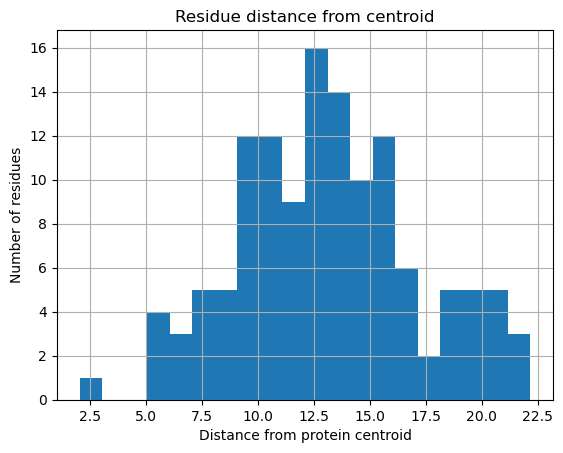

In [19]:
import matplotlib.pyplot as plt

residue_df["dist_from_centroid"].hist(bins=20)
plt.xlabel("Distance from protein centroid")
plt.ylabel("Number of residues")
plt.title("Residue distance from centroid")
plt.show()

***save the updated residue table***

In [20]:
from pathlib import Path

output_path = Path("../data/processed/residue_table.csv")
residue_df.to_csv(output_path, index=False)

print("Saved updated residue table to:", output_path)

Saved updated residue table to: ../data/processed/residue_table.csv


## Rough Structural Environment Labels

A first approximate structural environment label was added using Cα distance from the protein centroid.

### Labels
- `core`: residues closer to the protein center
- `surface`: residues farther from the protein center

### Why this matters
This provides a simple first approximation of mutational context and helps distinguish residues that may be more structurally constrained from those that may be more mutation-tolerant.

### Important limitation
This is a geometric heuristic, not a true solvent accessibility calculation. Later versions will use DSSP or SASA-based methods for more realistic surface/burial estimates.

***add sequence -order index***

In [21]:
residue_df = residue_df.sort_values(
    by=["chain_id", "residue_number", "insertion_code"]
).reset_index(drop=True)

residue_df["seq_index"] = range(len(residue_df))

residue_df.head()

,chain_id,residue_number,insertion_code,residue_name_3,residue_name_1,has_N,has_CA,has_C,has_O,ca_x,ca_y,ca_z,dist_from_centroid,environment,seq_index
0,A,1,,Lys,K,True,True,True,True,2.439,10.217,9.791,14.148950,surface,0
1,A,2,,Val,V,True,True,True,True,2.307,14.172,7.580,13.469238,surface,1
2,A,3,,Phe,F,True,True,True,True,-1.187,15.293,7.580,12.696476,core,2
3,A,4,,Gly,G,True,True,True,True,-2.637,17.468,4.864,14.780398,surface,3
4,A,5,,Arg,R,True,True,True,True,-3.823,20.764,5.685,13.922536,surface,4


***Add the simple geometric heuristic***

In [22]:
import numpy as np

# Start with default label
residue_df["ss_simple"] = "loop"

# Work chain by chain
for chain_id, chain_df in residue_df.groupby("chain_id"):
    chain_idx = chain_df.index.tolist()

    for i in range(1, len(chain_idx) - 1):
        prev_idx = chain_idx[i - 1]
        curr_idx = chain_idx[i]
        next_idx = chain_idx[i + 1]

        prev_ca = residue_df.loc[prev_idx, ["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=float)
        curr_ca = residue_df.loc[curr_idx, ["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=float)
        next_ca = residue_df.loc[next_idx, ["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=float)

        if np.any(np.isnan(prev_ca)) or np.any(np.isnan(curr_ca)) or np.any(np.isnan(next_ca)):
            continue

        v1 = curr_ca - prev_ca
        v2 = next_ca - curr_ca

        norm1 = np.linalg.norm(v1)
        norm2 = np.linalg.norm(v2)

        if norm1 == 0 or norm2 == 0:
            continue

        cos_angle = np.dot(v1, v2) / (norm1 * norm2)

        # Rough geometric rules:
        # straighter local geometry -> sheet-like
        # bent but regular -> helix-like
        # everything else -> loop
        if cos_angle > 0.35:
            residue_df.loc[curr_idx, "ss_simple"] = "sheet"
        elif -0.2 <= cos_angle <= 0.35:
            residue_df.loc[curr_idx, "ss_simple"] = "helix"
        else:
            residue_df.loc[curr_idx, "ss_simple"] = "loop"

***inspect results***

In [23]:
print(residue_df["ss_simple"].value_counts())

ss_simple
helix    97
sheet    30
loop      2
Name: count, dtype: int64


***Visualize the labels***

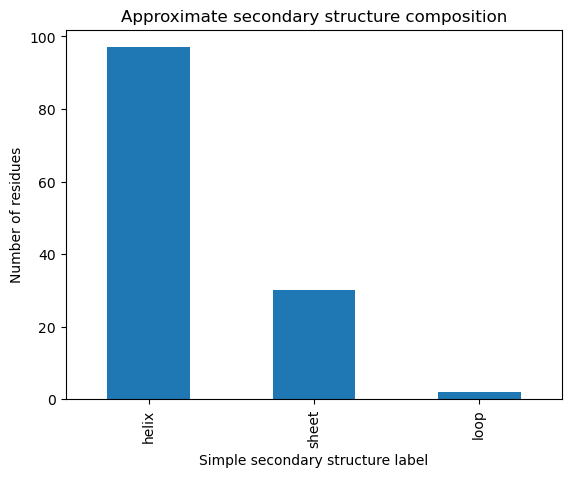

In [24]:
residue_df["ss_simple"].value_counts().plot(kind="bar")
plt.xlabel("Simple secondary structure label")
plt.ylabel("Number of residues")
plt.title("Approximate secondary structure composition")
plt.show()

***inspect a few rows***

In [25]:
residue_df[[
    "chain_id", "residue_number", "residue_name_1",
    "environment", "ss_simple"
]].head(20)

,chain_id,residue_number,residue_name_1,environment,ss_simple
0,A,1,K,surface,loop
1,A,2,V,surface,helix
2,A,3,F,core,sheet
3,A,4,G,surface,sheet
4,A,5,R,surface,helix
5,A,6,C,surface,helix
6,A,7,E,surface,helix
7,A,8,L,core,helix
8,A,9,A,core,helix
9,A,10,A,surface,helix


***save the updated table***

In [26]:
from pathlib import Path

output_path = Path("../data/processed/residue_table.csv")
residue_df.to_csv(output_path, index=False)

print("Saved updated residue table to:", output_path)

Saved updated residue table to: ../data/processed/residue_table.csv


## Approximate Secondary Structure Labels

A simple geometric heuristic was used to assign rough secondary-structure labels based on local Cα geometry.

### Labels
- `helix`
- `sheet`
- `loop`

### Why this matters
Secondary structure affects mutational tolerance, packing, and local backbone constraints.

### Important limitation
These labels are approximate and are not equivalent to DSSP or experimentally assigned secondary structure. A more rigorous annotation method will be added later.

***Mark structurally special residue types***

In [27]:
# Mark structurally special residue types
residue_df["is_special_residue"] = residue_df["residue_name_1"].isin(["G", "P", "C"])

def assign_mutation_priority(row):
    if (
        row["environment"] == "surface"
        and not row["is_special_residue"]
        and row["ss_simple"] in ["loop", "helix"]
    ):
        return "high"
    elif (
        row["environment"] == "core"
        or row["ss_simple"] == "sheet"
        or row["is_special_residue"]
    ):
        return "low"
    else:
        return "medium"

residue_df["mutation_priority"] = residue_df.apply(assign_mutation_priority, axis=1)

***add a reason string so the logic is explainable residue by residue.***

In [28]:
def mutation_reason(row):
    reasons = []

    if row["environment"] == "surface":
        reasons.append("surface")
    if row["environment"] == "core":
        reasons.append("core")

    if row["ss_simple"] == "loop":
        reasons.append("loop")
    elif row["ss_simple"] == "sheet":
        reasons.append("sheet")
    elif row["ss_simple"] == "helix":
        reasons.append("helix")

    if row["is_special_residue"]:
        reasons.append("special_residue")

    return ";".join(reasons)

residue_df["mutation_priority_reason"] = residue_df.apply(mutation_reason, axis=1)

***Inspect the results***

In [29]:
residue_df["mutation_priority"].value_counts()

mutation_priority
low     91
high    38
Name: count, dtype: int64

In [30]:
residue_df.groupby(["environment", "ss_simple", "is_special_residue"]).size().sort_values(ascending=False)

environment  ss_simple  is_special_residue
core         helix      False                 45
surface      helix      False                 36
core         sheet      False                 12
surface      helix      True                  12
             sheet      False                 12
core         helix      True                   4
             sheet      True                   3
surface      sheet      True                   3
             loop       False                  2
dtype: int64

In [31]:
residue_df[residue_df["mutation_priority"] == "medium"][
    ["chain_id", "residue_number", "residue_name_1", "environment", "ss_simple", "mutation_priority_reason"]
].head(20)

,chain_id,residue_number,residue_name_1,environment,ss_simple,mutation_priority_reason


In [32]:
residue_df[
    [
        "chain_id",
        "residue_number",
        "residue_name_1",
        "environment",
        "ss_simple",
        "is_special_residue",
        "mutation_priority",
        "mutation_priority_reason",
    ]
].head(50)

,chain_id,residue_number,residue_name_1,environment,ss_simple,is_special_residue,mutation_priority,mutation_priority_reason
0,A,1,K,surface,loop,False,high,surface;loop
1,A,2,V,surface,helix,False,high,surface;helix
2,A,3,F,core,sheet,False,low,core;sheet
3,A,4,G,surface,sheet,True,low,surface;sheet;special_residue
4,A,5,R,surface,helix,False,high,surface;helix
5,A,6,C,surface,helix,True,low,surface;helix;special_residue
6,A,7,E,surface,helix,False,high,surface;helix
7,A,8,L,core,helix,False,low,core;helix
8,A,9,A,core,helix,False,low,core;helix
9,A,10,A,surface,helix,False,high,surface;helix


***a summary plot***

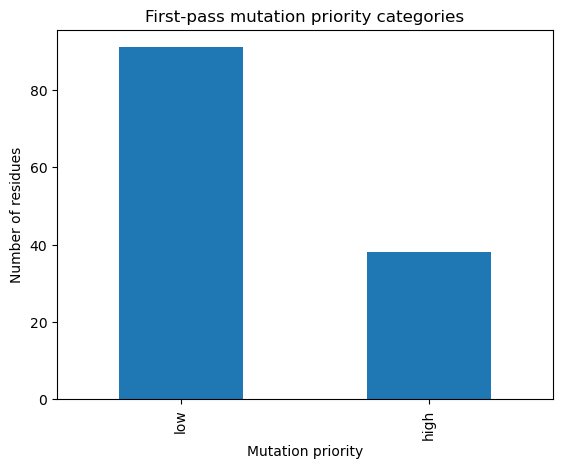

In [33]:
residue_df["mutation_priority"].value_counts().plot(kind="bar")
plt.xlabel("Mutation priority")
plt.ylabel("Number of residues")
plt.title("First-pass mutation priority categories")
plt.show()

***inspect top high-priority candidates***

In [34]:
high_priority_df = residue_df[residue_df["mutation_priority"] == "high"].copy()

high_priority_df[
    [
        "chain_id",
        "residue_number",
        "residue_name_1",
        "environment",
        "ss_simple",
        "mutation_priority_reason",
    ]
].head(20)

,chain_id,residue_number,residue_name_1,environment,ss_simple,mutation_priority_reason
0,A,1,K,surface,loop,surface;loop
1,A,2,V,surface,helix,surface;helix
4,A,5,R,surface,helix,surface;helix
6,A,7,E,surface,helix,surface;helix
9,A,10,A,surface,helix,surface;helix
12,A,13,K,surface,helix,surface;helix
13,A,14,R,surface,helix,surface;helix
17,A,18,D,surface,helix,surface;helix
18,A,19,N,surface,helix,surface;helix
20,A,21,R,surface,helix,surface;helix


***save the updated table***

In [35]:
from pathlib import Path

output_path = Path("../data/processed/residue_table.csv")
residue_df.to_csv(output_path, index=False)

print("Saved updated residue table to:", output_path)

Saved updated residue table to: ../data/processed/residue_table.csv


In [36]:
from pathlib import Path

high_priority_path = Path("../data/processed/high_priority_residues.csv")
high_priority_df.to_csv(high_priority_path, index=False)

print("Saved high-priority residues to:", high_priority_path)

Saved high-priority residues to: ../data/processed/high_priority_residues.csv


## First-Pass Mutation Priority

A simple heuristic mutation-priority label was added by combining structural environment, approximate secondary structure, and residue identity.

### Priority logic
- `high`: surface + (loop or helix) + not Gly/Pro/Cys
- `low`: core or sheet or Gly/Pro/Cys
- `medium`: intermediate cases

### Why this matters
This is the first interpretable residue-selection layer for engineering decisions.

### Important limitation
This is a heuristic prioritization scheme only. It does not account for active-site function, evolutionary conservation, energetic effects, or experimental validation.

Because the early secondary-structure labels are heuristic, high-priority selection was allowed for both surface-loop and surface-helix residues, while still excluding sheet-like and special residues conservatively.

***converting raw symbols like K, D, F, G into higher-level features***

In [37]:
def classify_aa(residue_1):
    if residue_1 in ["A", "V", "I", "L", "M"]:
        return "hydrophobic"
    elif residue_1 in ["S", "T", "N", "Q"]:
        return "polar"
    elif residue_1 in ["K", "R", "H"]:
        return "positive"
    elif residue_1 in ["D", "E"]:
        return "negative"
    elif residue_1 in ["F", "Y", "W"]:
        return "aromatic"
    elif residue_1 in ["G", "P", "C"]:
        return "special"
    else:
        return "unknown"

def classify_charge(residue_1):
    if residue_1 in ["K", "R", "H"]:
        return "positive"
    elif residue_1 in ["D", "E"]:
        return "negative"
    else:
        return "neutral"

residue_df["aa_class"] = residue_df["residue_name_1"].apply(classify_aa)
residue_df["aa_charge_class"] = residue_df["residue_name_1"].apply(classify_charge)

***Inspecting the results***

In [38]:
residue_df[
    [
        "residue_name_1",
        "aa_class",
        "aa_charge_class",
        "environment",
        "ss_simple",
        "mutation_priority",
    ]
].head(20)

,residue_name_1,aa_class,aa_charge_class,environment,ss_simple,mutation_priority
0,K,positive,positive,surface,loop,high
1,V,hydrophobic,neutral,surface,helix,high
2,F,aromatic,neutral,core,sheet,low
3,G,special,neutral,surface,sheet,low
4,R,positive,positive,surface,helix,high
5,C,special,neutral,surface,helix,low
6,E,negative,negative,surface,helix,high
7,L,hydrophobic,neutral,core,helix,low
8,A,hydrophobic,neutral,core,helix,low
9,A,hydrophobic,neutral,surface,helix,high


In [39]:
print(residue_df["aa_class"].value_counts())
print()
print(residue_df["aa_charge_class"].value_counts())

aa_class
hydrophobic    34
polar          34
special        22
positive       18
aromatic       12
negative        9
Name: count, dtype: int64

aa_charge_class
neutral     102
positive     18
negative      9
Name: count, dtype: int64


***visualization***

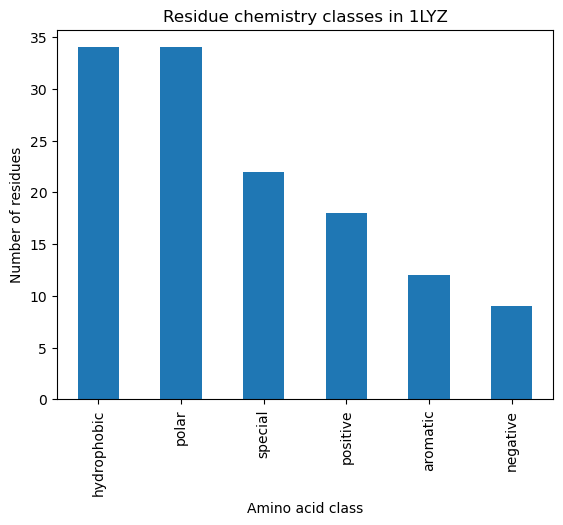

In [40]:
residue_df["aa_class"].value_counts().plot(kind="bar")
plt.xlabel("Amino acid class")
plt.ylabel("Number of residues")
plt.title("Residue chemistry classes in 1LYZ")
plt.show()

In [41]:
pd.crosstab(residue_df["aa_class"], residue_df["mutation_priority"])

mutation_priority,high,low
aa_class,,
aromatic,1,11
hydrophobic,7,27
negative,6,3
polar,12,22
positive,12,6
special,0,22


***save the updated table***

In [42]:
from pathlib import Path

output_path = Path("../data/processed/residue_table.csv")
residue_df.to_csv(output_path, index=False)

print("Saved updated residue table to:", output_path)

Saved updated residue table to: ../data/processed/residue_table.csv


## Residue Chemistry Classes

Basic biochemical residue classes were added to the residue table.

### Added features
- `aa_class`: hydrophobic, polar, positive, negative, aromatic, special
- `aa_charge_class`: positive, negative, neutral

### Why this matters
Mutation effects depend not only on structural position but also on amino-acid chemistry. These classes support interpretable reasoning about packing, polarity, charge, and mutation conservativeness.

### Important limitation
These are simplified categories and do not capture full physicochemical behavior, pKa context, side-chain geometry, or environment-dependent effects.

***first compact profile of the protein***

In [43]:
summary_counts = {
    "n_residues": len(residue_df),
    "n_chains": residue_df["chain_id"].nunique(),
    "n_core": (residue_df["environment"] == "core").sum(),
    "n_surface": (residue_df["environment"] == "surface").sum(),
    "n_high_priority": (residue_df["mutation_priority"] == "high").sum(),
    "n_medium_priority": (residue_df["mutation_priority"] == "medium").sum(),
    "n_low_priority": (residue_df["mutation_priority"] == "low").sum(),
}

summary_counts

{'n_residues': 129,
 'n_chains': 1,
 'n_core': np.int64(64),
 'n_surface': np.int64(65),
 'n_high_priority': np.int64(38),
 'n_medium_priority': np.int64(0),
 'n_low_priority': np.int64(91)}

***build summary table***

In [44]:
import pandas as pd

environment_counts = residue_df["environment"].value_counts().rename_axis("environment").reset_index(name="count")
ss_counts = residue_df["ss_simple"].value_counts().rename_axis("ss_simple").reset_index(name="count")
priority_counts = residue_df["mutation_priority"].value_counts().rename_axis("mutation_priority").reset_index(name="count")
aa_class_counts = residue_df["aa_class"].value_counts().rename_axis("aa_class").reset_index(name="count")
charge_counts = residue_df["aa_charge_class"].value_counts().rename_axis("aa_charge_class").reset_index(name="count")

environment_counts, ss_counts, priority_counts, aa_class_counts, charge_counts

(  environment  count
 0     surface     65
 1        core     64,
   ss_simple  count
 0     helix     97
 1     sheet     30
 2      loop      2,
   mutation_priority  count
 0               low     91
 1              high     38,
       aa_class  count
 0  hydrophobic     34
 1        polar     34
 2      special     22
 3     positive     18
 4     aromatic     12
 5     negative      9,
   aa_charge_class  count
 0         neutral    102
 1        positive     18
 2        negative      9)

***cross-tab summaries***

In [45]:
env_vs_class = pd.crosstab(residue_df["aa_class"], residue_df["environment"])
priority_vs_class = pd.crosstab(residue_df["aa_class"], residue_df["mutation_priority"])
ss_vs_environment = pd.crosstab(residue_df["ss_simple"], residue_df["environment"])

env_vs_class, priority_vs_class, ss_vs_environment

(environment  core  surface
 aa_class                  
 aromatic        9        3
 hydrophobic    26        8
 negative        3        6
 polar          15       19
 positive        4       14
 special         7       15,
 mutation_priority  high  low
 aa_class                    
 aromatic              1   11
 hydrophobic           7   27
 negative              6    3
 polar                12   22
 positive             12    6
 special               0   22,
 environment  core  surface
 ss_simple                 
 helix          49       48
 loop            0        2
 sheet          15       15)

***Save a compact summary CSV***|

In [46]:
summary_rows = []

for key, value in summary_counts.items():
    summary_rows.append({"category": "overall", "name": key, "count": int(value)})

for _, row in environment_counts.iterrows():
    summary_rows.append({"category": "environment", "name": row["environment"], "count": int(row["count"])})

for _, row in ss_counts.iterrows():
    summary_rows.append({"category": "secondary_structure", "name": row["ss_simple"], "count": int(row["count"])})

for _, row in priority_counts.iterrows():
    summary_rows.append({"category": "mutation_priority", "name": row["mutation_priority"], "count": int(row["count"])})

for _, row in aa_class_counts.iterrows():
    summary_rows.append({"category": "aa_class", "name": row["aa_class"], "count": int(row["count"])})

for _, row in charge_counts.iterrows():
    summary_rows.append({"category": "aa_charge_class", "name": row["aa_charge_class"], "count": int(row["count"])})

summary_df = pd.DataFrame(summary_rows)
summary_df.head(20)

,category,name,count
0,overall,n_residues,129
1,overall,n_chains,1
2,overall,n_core,64
3,overall,n_surface,65
4,overall,n_high_priority,38
5,overall,n_medium_priority,0
6,overall,n_low_priority,91
7,environment,surface,65
8,environment,core,64
9,secondary_structure,helix,97


In [47]:
from pathlib import Path

summary_path = Path("../data/processed/residue_summary_counts.csv")
summary_df.to_csv(summary_path, index=False)

print("Saved summary counts to:", summary_path)

Saved summary counts to: ../data/processed/residue_summary_counts.csv


## Residue Summary Interpretation

This summary condenses the residue-level table into a compact profile of the starting protein.

### What it captures
- protein size and chain count
- rough core vs surface balance
- rough secondary-structure composition
- mutation-priority distribution
- amino-acid chemistry composition

### Why this matters
Before starting real design, it is important to understand the overall structural and biochemical character of the target protein.

### Important limitation
These summaries depend partly on heuristic features such as centroid-based environment labels and simple secondary-structure approximation. They are useful for early interpretation but are not equivalent to rigorous structural annotation.

***visualization***

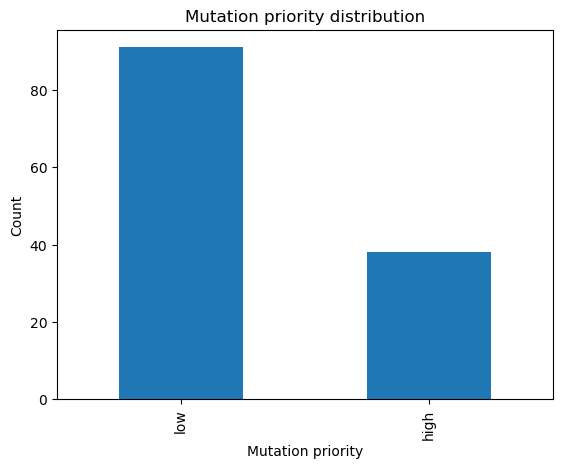

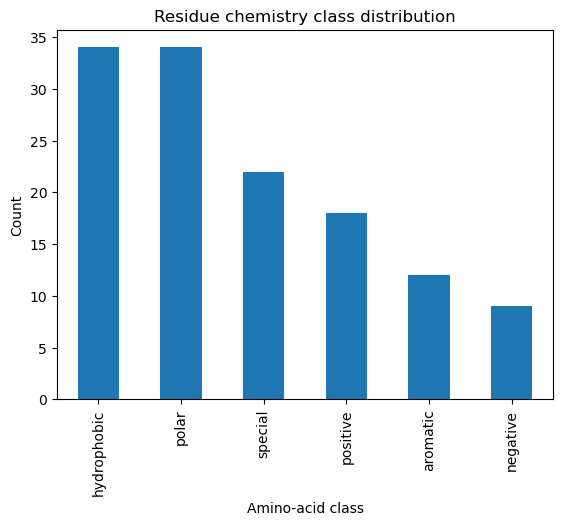

In [48]:
import matplotlib.pyplot as plt

priority_counts.plot(x="mutation_priority", y="count", kind="bar", legend=False)
plt.xlabel("Mutation priority")
plt.ylabel("Count")
plt.title("Mutation priority distribution")
plt.show()

aa_class_counts.plot(x="aa_class", y="count", kind="bar", legend=False)
plt.xlabel("Amino-acid class")
plt.ylabel("Count")
plt.title("Residue chemistry class distribution")
plt.show()

***file existance check***

In [49]:
from pathlib import Path
import pandas as pd

required_files = [
    "../data/raw/1LYZ.pdb",
    "../data/processed/residue_table.csv",
    "../data/processed/residue_summary_counts.csv",
]

optional_files = [
    "../data/processed/1LYZ_chain_A_sequence.txt",
    "../data/processed/high_priority_residues.csv",
]

rows = []

for file_path in required_files:
    p = Path(file_path)
    rows.append({
        "file_path": str(p),
        "file_type": "required",
        "exists": p.exists()
    })

for file_path in optional_files:
    p = Path(file_path)
    rows.append({
        "file_path": str(p),
        "file_type": "optional",
        "exists": p.exists()
    })

checklist_df = pd.DataFrame(rows)
checklist_df

,file_path,file_type,exists
0,../data/raw/1LYZ.pdb,required,True
1,../data/processed/residue_table.csv,required,True
2,../data/processed/residue_summary_counts.csv,required,True
3,../data/processed/1LYZ_chain_A_sequence.txt,optional,True
4,../data/processed/high_priority_residues.csv,optional,True


In [50]:
required_complete = checklist_df.loc[checklist_df["file_type"] == "required", "exists"].all()

print("All required v0 files present:", required_complete)

All required v0 files present: True
